# Thesis Project

## Student: Tairbek Akhayev 551094

# EEG Classification with KAN and Baseline Models


## 1. Setup and Imports


In [ ]:
# 1) Imports + config + basics
import os
import warnings
import yaml
import numpy as np
import torch

# графики оставим в ноутбуке; функции рисования — позже из code/visuals.py
import matplotlib.pyplot as plt

# подавим болтливость MNE
warnings.filterwarnings("ignore", category=UserWarning, module="mne")

# --- наш пайплайн из code/ ---
from kanlib.data_loading  import read_edf, save_file_record
from kanlib.preprocess import bandpass_notch
from kanlib.windowing import make_forecast_pairs
from kanlib.splits import split_by_file, loso_split
from kanlib.metrics import mae, rmse, smape
from kanlib.train import ForecastDataset, compute_channel_stats, train_loop

# модели подключим по мере необходимости
from kanlib.models.lstm import LSTMLite
from kanlib.models.kan import KANRegressor
# при желании: из models.linridge / tcn / xgb

# --- конфиг ---
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# --- устройство и сиды ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
np.random.seed(cfg.get("random_seed", 42))
torch.manual_seed(cfg.get("random_seed", 42))

print(f"Device: {device}")
print("Config loaded.")


Device: cpu
Config loaded.


In [ ]:
import os
import platform

# Читаем пути из config.yaml (если указаны)
data_dir = cfg.get("data", {}).get("raw_dir", None)
out_dir  = cfg.get("data", {}).get("out_dir", None)

if data_dir is None or out_dir is None:
    if platform.system() == "Windows":  # Azure Lab Services обычно под Windows
        data_dir = r"C:\Users\utente\Desktop\ThesisKAN\kanproject\dataverse_files"
        out_dir  = r"D:\thesis_data\processed"
    else:  # macOS/Linux (твой локальный ноут)
        data_dir = "/Users/tairakhayev/Desktop/ThesisProject/dataverse_files"
        out_dir  = os.path.abspath("./processed")

# записываем в переменные окружения (для совместимости с твоим старым кодом)
os.environ["THESIS_DATA_DIR"] = data_dir
os.environ["THESIS_OUT_DIR"]  = out_dir

print(f"Data dir: {data_dir}")
print(f"Out dir:  {out_dir}")


Data dir: /Users/tairakhayev/Desktop/ThesisProject/dataverse_files
Out dir:  ./processed


## 2. Load and Explore EDF Files


In [ ]:
# ==== Data discovery (recursive glob from config.yaml) ====
import os
from glob import glob

DATA_DIR = cfg["data"]["raw_dir"]
assert DATA_DIR and os.path.isdir(DATA_DIR), f"DATA_DIR not found: {DATA_DIR}"

edf_lower = glob(os.path.join(DATA_DIR, "**", "*.edf"), recursive=True)
edf_upper = glob(os.path.join(DATA_DIR, "**", "*.EDF"), recursive=True)
all_files = sorted(set(edf_lower + edf_upper))

print("DATA_DIR:", DATA_DIR)
print(f"Total EDF files found (recursive): {len(all_files)}")
for i, fp in enumerate(all_files[:5]):
    print(f"[{i+1}] {fp}")



DATA_DIR: /Users/tairakhayev/Desktop/ThesisProject/dataverse_files
Total EDF files found (recursive): 28
[1] /Users/tairakhayev/Desktop/ThesisProject/dataverse_files/h01.edf
[2] /Users/tairakhayev/Desktop/ThesisProject/dataverse_files/h02.edf
[3] /Users/tairakhayev/Desktop/ThesisProject/dataverse_files/h03.edf
[4] /Users/tairakhayev/Desktop/ThesisProject/dataverse_files/h04.edf
[5] /Users/tairakhayev/Desktop/ThesisProject/dataverse_files/h05.edf


In [ ]:
# ==== Inspect channel names + check desired channels from config ====
import os
import mne

desired = cfg["data"]["channels"]  # твои 9 каналов из config.yaml

def normalize_names(names):
    # приводим к верхнему регистру и убираем пробелы/подчёркивания для устойчивого сравнения
    return {n.upper().replace(" ", "").replace("_", ""): n for n in names}

def find_channel_mapping(file_channels, desired_channels):
    """
    Возвращает:
      - mapping: словарь {оригинальное_имя_в_raw -> желаемое_имя_из_config}
      - missing: список каналов из config, которых нет в файле
    Сопоставление нечувствительно к регистру/пробелам/подчёркиваниям.
    """
    raw_norm = normalize_names(file_channels)          # norm -> original
    want_norm = {ch.upper().replace(" ", "").replace("_", ""): ch for ch in desired_channels}
    mapping = {}
    for k_norm, want_name in want_norm.items():
        if k_norm in raw_norm:
            mapping[ raw_norm[k_norm] ] = want_name
    missing = [want_name for k_norm, want_name in want_norm.items() if k_norm not in raw_norm]
    return mapping, missing

sample_files = all_files[:4]

for fp in sample_files:
    try:
        raw_hdr = mne.io.read_raw_edf(fp, preload=False, verbose=False)
        ch_names = raw_hdr.ch_names
        preview = ch_names[:10]
        suffix = " ..." if len(ch_names) > 10 else ""
        mapping, missing = find_channel_mapping(ch_names, desired)

        print(f"\n{os.path.basename(fp)} -> {preview}{suffix} (total {len(ch_names)} channels)")
        if mapping:
            found_pretty = [f"{src}→{dst}" if src != dst else dst for src, dst in mapping.items()]
            print("  ✓ Found (mapped):", ", ".join(found_pretty))
        if missing:
            print("  ✗ Missing:", ", ".join(missing))
        else:
            print("  ✓ All desired channels present.")
    except Exception as e:
        print(f"\nError reading {os.path.basename(fp)}: {e}")



h01.edf -> ['Fp2', 'F8', 'T4', 'T6', 'O2', 'Fp1', 'F7', 'T3', 'T5', 'O1'] ... (total 19 channels)
  ✓ Found (mapped): Fp1, Fp2, Fz, C3, C4, Pz, O1, O2, Cz
  ✓ All desired channels present.

h02.edf -> ['Fp2', 'F8', 'T4', 'T6', 'O2', 'Fp1', 'F7', 'T3', 'T5', 'O1'] ... (total 19 channels)
  ✓ Found (mapped): Fp1, Fp2, Fz, C3, C4, Pz, O1, O2, Cz
  ✓ All desired channels present.

h03.edf -> ['Fp2', 'F8', 'T4', 'T6', 'O2', 'Fp1', 'F7', 'T3', 'T5', 'O1'] ... (total 19 channels)
  ✓ Found (mapped): Fp1, Fp2, Fz, C3, C4, Pz, O1, O2, Cz
  ✓ All desired channels present.

h04.edf -> ['Fp2', 'F8', 'T4', 'T6', 'O2', 'Fp1', 'F7', 'T3', 'T5', 'O1'] ... (total 19 channels)
  ✓ Found (mapped): Fp1, Fp2, Fz, C3, C4, Pz, O1, O2, Cz
  ✓ All desired channels present.


In [ ]:
# ==== Validate that all desired channels are present in each file ====
import os, mne

desired = cfg["data"]["channels"]
missing_report = []

for fp in all_files:
    try:
        raw_hdr = mne.io.read_raw_edf(fp, preload=False, verbose=False)
        ch_names = raw_hdr.ch_names
        present = set(ch_names)
        missing = [ch for ch in desired if ch not in present]
        if missing:
            missing_report.append((os.path.basename(fp), missing))
    except Exception as e:
        missing_report.append((os.path.basename(fp), [f"read_error: {e}"]))

if not missing_report:
    print("✓ All desired channels present in all files.")
else:
    print(f"⚠ Files with missing desired channels: {len(missing_report)}")
    for fname, miss in missing_report[:10]:
        print(f" - {fname}: missing {miss}")
    if len(missing_report) > 10:
        print(" ... (truncated)")


✓ All desired channels present in all files.


## 3. Channel Selection 

<Figure size 600x600 with 0 Axes>

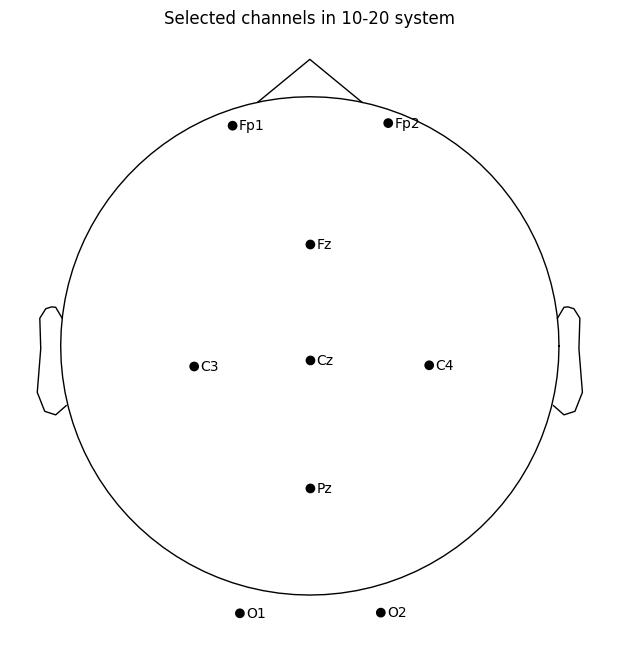

Fp1: [-0.0294367  0.0839171 -0.00699  ]
Fp2: [ 0.0298723  0.0848959 -0.00708  ]
Fz: [0.0003122 0.058512  0.066462 ]
C3: [-0.0653581 -0.0116317  0.064358 ]
C4: [ 0.0671179 -0.0109003  0.06358  ]
Pz: [ 0.0003247 -0.081115   0.082615 ]
O1: [-0.0294134 -0.112449   0.008839 ]
O2: [ 0.0298426 -0.112156   0.0088   ]
Cz: [ 0.0004009 -0.009167   0.100244 ]


In [ ]:
# ==== Optional: visualize selected channels (for thesis figures) ====
import mne
import matplotlib.pyplot as plt

def plot_selected_channels(selected_channels):
    """
    Рисует расположение выбранных каналов в системе 10-20.
    """
    montage = mne.channels.make_standard_montage("standard_1020")
    ch_pos_all = montage.get_positions()["ch_pos"]

    # fallback для альтернативных имён (если вдруг встретятся)
    viz_map = {"T3": "T7", "T4": "T8"}

    viz_channels = []
    for ch in selected_channels:
        base = viz_map.get(ch, ch)
        # пробуем разные варианты регистра
        candidates = [base, base.capitalize(), base.upper()]
        vch = next((c for c in candidates if c in ch_pos_all), None)
        viz_channels.append(vch)

    sel_pos = {ch: ch_pos_all[vch] for ch, vch in zip(selected_channels, viz_channels) if vch is not None}
    missing = [ch for ch, vch in zip(selected_channels, viz_channels) if vch is None]
    if missing:
        print("⚠️ Missing in standard_1020:", missing)

    sel_montage = mne.channels.make_dig_montage(ch_pos=sel_pos, coord_frame="head")
    fig = plt.figure(figsize=(6, 6))
    mne.viz.plot_montage(sel_montage, show_names=True, sphere=0.1, show=False)
    plt.title("Selected channels in 10-20 system")
    plt.show()

    # координаты (если пригодятся для приложения)
    for ch, pos in sel_pos.items():
        print(f"{ch}: {pos}")

# вызов из конфигурации (без хардкода)
plot_selected_channels(cfg["data"]["channels"])


## Step 3.3  Build dataset and save artifacts



In [69]:
# === Build forecast pairs (with diagnostics; no normalization) ===
import os
import numpy as np
from kanlib.data_loading import read_edf
from kanlib.preprocess import bandpass_notch
from kanlib.windowing import make_forecast_pairs

save_dir = cfg["data"]["out_dir"]
os.makedirs(save_dir, exist_ok=True)

pick_channels = cfg["data"]["channels"]
fs_target     = cfg["data"]["fs_target"]
bp_lo, bp_hi  = cfg["data"]["bandpass"]
notches       = tuple(cfg["data"]["notch"])

L       = cfg["task"]["L"]
H       = cfg["task"]["H"]
stride  = cfg["task"]["stride"]
tmode   = cfg["task"]["target_mode"]   # "uni" | "multi"
tch_name = cfg["task"]["target_channel"]

# индекс целевого канала для uni
if tmode == "uni":
    try:
        t_ch = pick_channels.index(tch_name)
    except ValueError:
        raise ValueError(f"target_channel '{tch_name}' not in data.channels {pick_channels}")
else:
    t_ch = 0  # не используется

X_list, Y_list, file_ids = [], [], []

diag = {
    "ok_files": 0,
    "short_files": [],       # T < L+H
    "zero_pairs": [],        # формально достаточно, но из-за stride получилось 0
    "errors": [],            # исключения
    "samples": []            # (fname, T, fs, n_pairs)
}

def infer_ids(filepath: str):
    base = os.path.basename(filepath)
    stem = os.path.splitext(base)[0]
    return stem, stem

for i, fp in enumerate(all_files, 1):
    fname = os.path.basename(fp)
    try:
        arr, fs = read_edf(fp, pick_channels=pick_channels, fs_target=fs_target)  # [C,T]
        arr = bandpass_notch(arr.astype(np.float64, copy=False), fs=fs, band=(bp_lo, bp_hi), notch=notches)     # [C,T]
        C, T = arr.shape

        if T < (L + H):
            diag["short_files"].append((fname, T, fs))
            if i % 5 == 0 or i == len(all_files):
                print(f"[{i}/{len(all_files)}] {fname} -> TOO SHORT (T={T} < L+H={L+H})")
            continue

        pairs = make_forecast_pairs(arr, L=L, H=H, stride=stride, target_mode=tmode, target_ch=t_ch)
        n_pairs = len(pairs)

        if n_pairs == 0:
            diag["zero_pairs"].append((fname, T, fs, L, H, stride))
            if i % 5 == 0 or i == len(all_files):
                print(f"[{i}/{len(all_files)}] {fname} -> 0 pairs (T={T}, L={L}, H={H}, stride={stride})")
            continue

        Xi = [p[0] for p in pairs]
        Yi = [p[1] for p in pairs]
        X_list.extend(Xi)
        Y_list.extend(Yi)

        fid, sid = infer_ids(fp)
        file_ids.extend([fid] * n_pairs)

        diag["ok_files"] += 1
        diag["samples"].append((fname, T, fs, n_pairs))
        if i % 5 == 0 or i == len(all_files):
            print(f"[{i}/{len(all_files)}] {fname} -> +{n_pairs} pairs (T={T}, fs={fs})")

    except Exception as e:
        diag["errors"].append((fname, str(e)))
        print(f"[WARN] skip {fname}: {e}")

if len(X_list) == 0:
    print("\n=== DIAGNOSTICS ===")
    print(f"OK files: {diag['ok_files']}")
    print(f"Too short (T < L+H={L+H}): {len(diag['short_files'])}")
    for r in diag["short_files"][:5]:
        print("  -", r)
    print(f"Zero pairs (check stride/L/H): {len(diag['zero_pairs'])}")
    for r in diag["zero_pairs"][:5]:
        print("  -", r)
    print(f"Errors while reading/filtering: {len(diag['errors'])}")
    for r in diag["errors"][:3]:
        print("  -", r)
    raise RuntimeError("No forecast pairs produced. Consider decreasing L or H, or using smaller stride.")

# Конвертируем в массивы (без нормализации)
X = np.stack(X_list).astype(np.float32)                 # [N, C, L]
Y = np.stack(Y_list).astype(np.float32)                 # [N, H] или [N, C, H]
file_ids = np.array(file_ids, dtype=object)             # [N]

C = len(pick_channels)
assert X.ndim == 3 and X.shape[1] == C and X.shape[2] == L, f"Unexpected X shape: {X.shape}"
if tmode == "uni":
    assert Y.ndim == 2 and Y.shape[1] == H, f"Unexpected Y shape for uni: {Y.shape}"
else:
    assert Y.ndim == 3 and Y.shape[1] == C and Y.shape[2] == H, f"Unexpected Y shape for multi: {Y.shape}"

np.save(os.path.join(save_dir, "X_raw.npy"), X)
np.save(os.path.join(save_dir, "Y_raw.npy"), Y)
np.save(os.path.join(save_dir, "file_ids.npy"), file_ids)
np.save(os.path.join(save_dir, "channels.npy"), np.array(pick_channels, dtype=object))

print("\nSaved to:", save_dir)
print("X_raw:", X.shape, X.dtype, "| Y_raw:", Y.shape, Y.dtype)
print("Unique files in pairs:", len(np.unique(file_ids)))
print("Pairs per first 3 files:", {fid: (file_ids == fid).sum() for fid in np.unique(file_ids)[:3]})


[5/28] h05.edf -> +943 pairs (T=236250, fs=250.0)
[10/28] h10.edf -> +1113 pairs (T=278750, fs=250.0)
[15/28] s01.edf -> +843 pairs (T=211250, fs=250.0)
[20/28] s06.edf -> +738 pairs (T=185000, fs=250.0)
[25/28] s11.edf -> +1358 pairs (T=340000, fs=250.0)
[28/28] s14.edf -> +2168 pairs (T=542500, fs=250.0)

Saved to: ./processed
X_raw: (28807, 9, 500) float32 | Y_raw: (28807, 125) float32
Unique files in pairs: 28
Pairs per first 3 files: {'h01': 923, 'h02': 908, 'h03': 908}


## 8. Load and Split Data

- Load X and y from saved files
- Split into train (80%) and test (20%) sets
- Create PyTorch Dataset and DataLoader

In [70]:
# ==== Load raw pairs, group-split by file, compute train stats, build loaders ====
import os
import numpy as np

from kanlib.splits import split_by_file
from kanlib.train import ForecastDataset, compute_channel_stats

save_dir = cfg["data"]["out_dir"]
assert os.path.isdir(save_dir), f"Out dir not found: {save_dir}"

# файлы, которые мы сохраняли на предыдущем шаге
X_path        = os.path.join(save_dir, "X_raw.npy")
Y_path        = os.path.join(save_dir, "Y_raw.npy")
file_ids_path = os.path.join(save_dir, "file_ids.npy")
channels_path = os.path.join(save_dir, "channels.npy")

for p in [X_path, Y_path, file_ids_path, channels_path]:
    assert os.path.isfile(p), f"Missing artifact: {p}"

X = np.load(X_path)               # [N, C, L], float32
Y = np.load(Y_path)               # [N, H] or [N, C, H], float32
file_ids = np.load(file_ids_path, allow_pickle=True)  # [N], object
channels = np.load(channels_path, allow_pickle=True).tolist()

C, L = X.shape[1], X.shape[2]
tmode = cfg["task"]["target_mode"]
H = Y.shape[1] if tmode == "uni" else Y.shape[2]

# --- сплит по файлам (60/20/20 по config) ---
ratios = tuple(cfg["split"]["ratios"])
train_files, val_files, test_files = split_by_file(file_ids, ratios=ratios, seed=cfg.get("random_seed", 42))

train_mask = np.isin(file_ids, list(train_files))
val_mask   = np.isin(file_ids, list(val_files))
test_mask  = np.isin(file_ids, list(test_files))

X_train, Y_train = X[train_mask], Y[train_mask]
X_val,   Y_val   = X[val_mask],   Y[val_mask]
X_test,  Y_test  = X[test_mask],  Y[test_mask]

assert len(X_train) and len(X_val) and len(X_test), "Empty split — check ratios or file_ids."

# --- считаем ТОЛЬКО ПО TRAIN пер-канальные mean/std ---
train_mean, train_std = compute_channel_stats(list(X_train))  # shapes: [C], [C]

# индекс целевого канала для режима "uni"
if tmode == "uni":
    target_ch_name = cfg["task"]["target_channel"]
    try:
        target_ch_idx = channels.index(target_ch_name)
    except ValueError:
        raise ValueError(f"target_channel {target_ch_name} not found in channels {channels}")
else:
    target_ch_idx = 0  # не используется

# --- собираем датасеты (нормализация внутри ForecastDataset по train_mean/std) ---
train_ds = ForecastDataset(X_train, Y_train, mean=train_mean, std=train_std,
                           target_mode=tmode, target_ch_idx=target_ch_idx, norm_y=True)
val_ds   = ForecastDataset(X_val,   Y_val,   mean=train_mean, std=train_std,
                           target_mode=tmode, target_ch_idx=target_ch_idx, norm_y=True)
test_ds  = ForecastDataset(X_test,  Y_test,  mean=train_mean, std=train_std,
                           target_mode=tmode, target_ch_idx=target_ch_idx, norm_y=True)

from torch.utils.data import DataLoader
bs = cfg["train"]["batch_size"]

train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=bs, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False, drop_last=False)

print("Split (pairs):",
      f"train={len(train_ds)} | val={len(val_ds)} | test={len(test_ds)}")
print("Shapes:",
      f"X: [N,{C},{L}]  Y: [{'H' if tmode=='uni' else f'C,{H}'}]  -> L={L}, H={H}, C={C}")
print("Target mode:", tmode, "| target channel (uni):", (channels[target_ch_idx] if tmode=='uni' else "—"))


Split (pairs): train=16713 | val=6211 | test=5883
Shapes: X: [N,9,500]  Y: [H]  -> L=500, H=125, C=9
Target mode: uni | target channel (uni): Pz


## 9. KAN Model with PyTorch + PyKAN

Steps:
- Flatten EEG window (19×500 → 9500 features)
- Pass through Kolmogorov–Arnold Network (KAN)
- Output 2 classes (Healthy vs Parkinson)


In [71]:
# ==== 9. Select model (KAN) + train for forecasting (uni/multi) ====
import os, torch, numpy as np

from kanlib.models.kan import KANRegressor
from kanlib.train import train_loop
from kanlib.metrics import mae, rmse, smape

# модель из конфига
tmode = cfg["task"]["target_mode"]       # "uni" | "multi"
C, L    = X.shape[1], X.shape[2]
H       = Y.shape[1] if tmode=="uni" else Y.shape[2]

model = KANRegressor(C=C, L=L, H=H, target_mode=tmode, **cfg.get("model", {}).get("params", {})).to(device)

# лосс
loss_name = cfg["train"].get("loss", "mse").lower()
if loss_name == "mse":
    loss_fn = torch.nn.MSELoss()
elif loss_name == "l1":
    loss_fn = torch.nn.L1Loss()
elif loss_name == "smoothl1":
    loss_fn = torch.nn.SmoothL1Loss()
else:
    raise ValueError(f"Unknown loss: {loss_name}")

# оптимизатор
optimizer = torch.optim.Adam(model.parameters(), lr=float(cfg["train"]["lr"]))

# обучение с early stopping по val loss (RMSE эквивалентен MSE по критерию минимума)
out_dir = cfg["logging"]["out_dir"]
os.makedirs(out_dir, exist_ok=True)
ckpt_path = os.path.join(out_dir, "best_kan.pt")

history = train_loop(
    model=model,
    loaders={"train": train_loader, "val": val_loader},
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device,
    epochs=int(cfg["train"]["epochs"]),
    patience=int(cfg["train"]["early_stopping_patience"]),
    save_path=ckpt_path,
)

print("Best checkpoint:", ckpt_path)

# ==== Evaluate on test (denormalize back for metrics) ====
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

def predict_loader(model, loader):
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yhat = model(xb).cpu().numpy()
            ytrue = yb.cpu().numpy()
            preds.append(yhat); trues.append(ytrue)
    return np.concatenate(preds, axis=0), np.concatenate(trues, axis=0)

yhat_norm, ytrue_norm = predict_loader(model, test_loader)

# денормализация для метрик
if tmode == "uni":
    ch_idx = target_ch_idx  # из предыдущей ячейки сплита
    yhat = yhat_norm * (train_std[ch_idx] + 1e-6) + train_mean[ch_idx]
    ytrue = ytrue_norm * (train_std[ch_idx] + 1e-6) + train_mean[ch_idx]
else:
    yhat = yhat_norm * (train_std[:, None] + 1e-6) + train_mean[:, None]
    ytrue = ytrue_norm * (train_std[:, None] + 1e-6) + train_mean[:, None]

# усредняем по горизонту (и по каналам, если multi) для одной цифры на сэмпл
if tmode == "uni":
    yhat_flat  = yhat
    ytrue_flat = ytrue
else:
    yhat_flat  = yhat.mean(axis=1)   # [N, H]
    ytrue_flat = ytrue.mean(axis=1)  # [N, H]

test_mae  = mae(ytrue_flat, yhat_flat)
test_rmse = rmse(ytrue_flat, yhat_flat)
test_smape= smape(ytrue_flat, yhat_flat)

print(f"Test metrics: MAE={test_mae:.4f} | RMSE={test_rmse:.4f} | sMAPE={test_smape:.2f}%")


Best checkpoint: outputs/best_kan.pt
Test metrics: MAE=0.0000 | RMSE=0.0000 | sMAPE=147.41%


In [72]:
# ==== KAN for forecasting (regression, not classification) ====
import torch
from kanlib.models.kan import KANRegressor

tmode = cfg["task"]["target_mode"]       # "uni" | "multi"
C, L   = X.shape[1], X.shape[2]
H      = Y.shape[1] if tmode == "uni" else Y.shape[2]

# Модель (по умолчанию avgpool k=s=10 → 500→50, затем KAN-блок + linear head)
model = KANRegressor(
    C=C, L=L, H=H,
    pool=5,                 # было 10 → берём детальнее
    hidden=(64, 32),
    target_mode=cfg["task"]["target_mode"],
    grid=3, k=3
).to(device)

# Лосс для регрессии
loss_name = cfg["train"].get("loss", "mse").lower()
if loss_name == "mse":
    loss_fn = torch.nn.MSELoss()
elif loss_name == "l1":
    loss_fn = torch.nn.L1Loss()
elif loss_name == "smoothl1":
    loss_fn = torch.nn.SmoothL1Loss()
else:
    raise ValueError(f"Unknown loss: {loss_name}")

# Оптимизатор
optimizer = torch.optim.Adam(model.parameters(), lr=float(cfg["train"]["lr"]))

print(f"Model: KANRegressor | mode={tmode} | C={C} L={L} H={H}")
print("Device:", device)


TypeError: KANRegressor.__init__() got an unexpected keyword argument 'pool'

In [ ]:
from pathlib import Path
from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm
import torch, os, math

# AMP включаем только на CUDA
use_amp = (device.type == "cuda")
scaler  = GradScaler("cuda", enabled=use_amp)

# Каталог чекпоинтов — берём из конфига
CKPT_DIR = Path(cfg["logging"]["out_dir"])
CKPT_DIR.mkdir(parents=True, exist_ok=True)
BEST  = CKPT_DIR / "best_kan.pt"
LAST  = CKPT_DIR / "last_kan.pt"
FINAL = CKPT_DIR / "final_kan.pt"
print("Checkpoints will be saved to:", CKPT_DIR.resolve())

@torch.no_grad()
def evaluate_val_rmse(model, loader):
    """
    Считает средний RMSE по валидационному лоадеру.
    ВНИМАНИЕ: это RMSE в нормализованном пространстве (и этого достаточно для early stopping).
    Финальные метрики на test мы посчитаем позже после денормализации.
    """
    model.eval()
    se_sum = 0.0
    n_elem = 0
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        with autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            yhat = model(xb)
        # приводим к одинаковой форме и считаем сумму квадратов ошибок
        diff = (yhat - yb).float()
        se_sum += torch.sum(diff * diff).item()
        n_elem += diff.numel()
    mse = se_sum / max(1, n_elem)
    rmse = math.sqrt(mse)
    return rmse

def train(model, train_loader, val_loader, epochs=cfg["train"]["epochs"], patience=cfg["train"]["early_stopping_patience"]):
    best_rmse = float("inf")
    stale = 0

    for epoch in range(1, int(epochs)+1):
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
                yhat = model(xb)
                loss = loss_fn(yhat, yb)     # loss_fn определён в предыдущей ячейке (mse/l1/smoothl1)
            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train_loss = running_loss / max(1, len(train_loader))
        val_rmse = evaluate_val_rmse(model, val_loader)
        print(f"[END] Epoch {epoch:02d} | train_loss={avg_train_loss:.4f} | val_RMSE(norm)={val_rmse:.4f} | best={min(best_rmse, val_rmse):.4f}")

        # сохраняем LAST каждый эпох
        torch.save(model.state_dict(), LAST)

        # early stopping по валид. RMSE
        if val_rmse < best_rmse - 1e-6:
            best_rmse, stale = val_rmse, 0
            torch.save(model.state_dict(), BEST)
        else:
            stale += 1
            if stale >= int(patience):
                print(f"Early stopping. Best val_RMSE(norm) = {best_rmse:.4f}")
                break

    # финальная копия текущего состояния
    torch.save(model.state_dict(), FINAL)
    print("Saved:\n ",
          "BEST :", BEST.resolve(),  "exists:", BEST.exists(), "\n ",
          "LAST :", LAST.resolve(),  "exists:", LAST.exists(), "\n ",
          "FINAL:", FINAL.resolve(), "exists:", FINAL.exists())
    return best_rmse

best_val_rmse = train(model, train_loader, val_loader,
                      epochs=cfg["train"]["epochs"],
                      patience=cfg["train"]["early_stopping_patience"])
print(f"Best val_RMSE (normalized): {best_val_rmse:.4f}")


Checkpoints will be saved to: /Users/tairakhayev/Desktop/ThesisProject/TimeSeriesForecast/outputs


Epoch 1/100:   0%|          | 0/262 [00:00<?, ?it/s]

[END] Epoch 01 | train_loss=0.2515 | val_RMSE(norm)=0.4869 | best=0.4869


Epoch 2/100:   0%|          | 0/262 [00:00<?, ?it/s]

[END] Epoch 02 | train_loss=0.2997 | val_RMSE(norm)=0.4805 | best=0.4805


...

[END] Epoch 15 | train_loss=0.1587 | val_RMSE(norm)=0.5327 | best=0.4805


Epoch 16/100:   0%|          | 0/262 [00:00<?, ?it/s]

[END] Epoch 16 | train_loss=0.1586 | val_RMSE(norm)=0.5630 | best=0.4805


Epoch 17/100:   0%|          | 0/262 [00:00<?, ?it/s]

[END] Epoch 17 | train_loss=0.1491 | val_RMSE(norm)=0.6080 | best=0.4805
Early stopping. Best val_RMSE(norm) = 0.4805
Saved:
  BEST : /Users/tairakhayev/Desktop/ThesisProject/TimeSeriesForecast/outputs/best_kan.pt exists: True 
  LAST : /Users/tairakhayev/Desktop/ThesisProject/TimeSeriesForecast/outputs/last_kan.pt exists: True 
  FINAL: /Users/tairakhayev/Desktop/ThesisProject/TimeSeriesForecast/outputs/final_kan.pt exists: True
Best val_RMSE (normalized): 0.4805


TEST: MAE=0.0000 | RMSE=0.0000 | sMAPE=156.64%
Saved: outputs/metrics_test.json | outputs/metrics_test_horizon.csv | outputs/metrics_test_by_file.csv


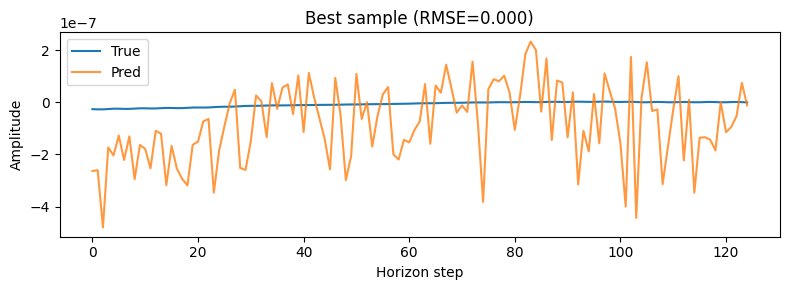

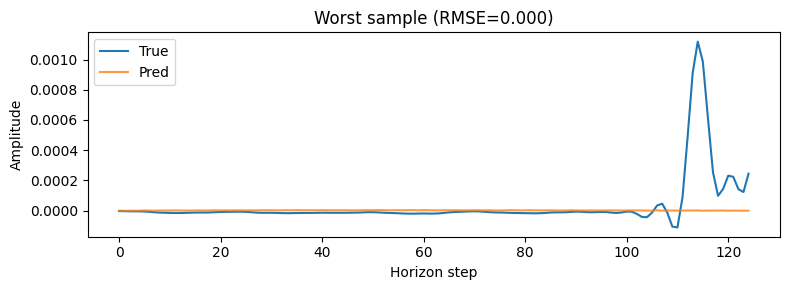

/var/folders/bq/30vr00796qb9hcgw3924qw200000gn/T/ipykernel_62172/1815510546.py:128: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([g["rmse"].values for _, g in df_file.groupby("file_id")],


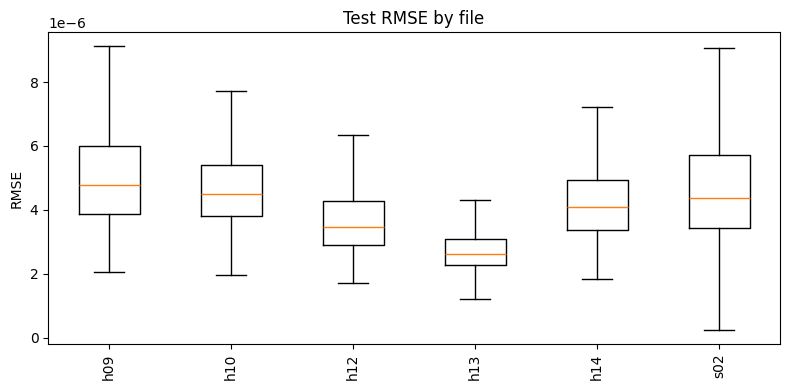

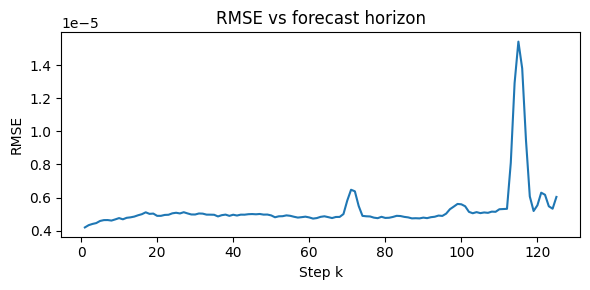

In [ ]:
# ==== Test inference + denorm + metrics + save + plots ====
import os, json, numpy as np, torch
import matplotlib.pyplot as plt
import pandas as pd
from kanlib.metrics import mae, rmse, smape

# 1) Load best checkpoint & predict on test
model.load_state_dict(torch.load(BEST, map_location=device))
model.eval()

@torch.no_grad()
def predict_loader(model, loader):
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        with autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            yhat = model(xb)
        preds.append(yhat.cpu().numpy())
        trues.append(yb.cpu().numpy())
    return np.concatenate(preds, axis=0), np.concatenate(trues, axis=0)

yhat_norm, ytrue_norm = predict_loader(model, test_loader)

# 2) Denormalize (using train stats)
def denorm_uni(arr):   # arr: [N,H]
    ch = target_ch_idx
    return arr * (float(train_std[ch]) + 1e-6) + float(train_mean[ch])

def denorm_multi(arr): # arr: [N,C,H]
    return arr * (train_std[:, None] + 1e-6) + (train_mean[:, None])

tmode = cfg["task"]["target_mode"]
if tmode == "uni":
    yhat = denorm_uni(yhat_norm)
    ytrue = denorm_uni(ytrue_norm)
else:
    yhat = denorm_multi(yhat_norm)
    ytrue = denorm_multi(ytrue_norm)

# 3) Global metrics (average over horizon; and over channels if multi)
if tmode == "uni":
    # per-sample rmse over horizon
    rmse_per_sample = np.sqrt(np.mean((yhat - ytrue) ** 2, axis=1))  # [N]
    mae_val   = mae(ytrue, yhat)
    rmse_val  = rmse(ytrue, yhat)
    smape_val = smape(ytrue, yhat)
    H = yhat.shape[1]
    # horizon-wise RMSE (length H)
    rmse_h = np.sqrt(np.mean((yhat - ytrue) ** 2, axis=0))
else:
    # average across channels first for scalar metrics
    diff = yhat - ytrue
    rmse_per_sample = np.sqrt(np.mean(diff ** 2, axis=(1, 2)))       # [N]
    mae_val   = mae(ytrue.mean(axis=1), yhat.mean(axis=1))
    rmse_val  = rmse(ytrue.mean(axis=1), yhat.mean(axis=1))
    smape_val = smape(ytrue.mean(axis=1), yhat.mean(axis=1))
    H = yhat.shape[2]
    # horizon-wise RMSE averaged over channels
    rmse_h = np.sqrt(np.mean(diff ** 2, axis=(0, 1)))                # [H]

print(f"TEST: MAE={mae_val:.4f} | RMSE={rmse_val:.4f} | sMAPE={smape_val:.2f}%")

# 4) File-wise metrics (for boxplot)
# try to reuse file_ids & test_mask from split; if not present, load and re-mask
try:
    file_ids_test = file_ids[test_mask]
except NameError:
    file_ids_all = np.load(os.path.join(save_dir, "file_ids.npy"), allow_pickle=True)
    try:
        # if we still have test_files from split
        file_ids_test = file_ids_all[np.isin(file_ids_all, list(test_files))]
    except NameError:
        # fallback: align lengths (assumes current test set order matches previous creation)
        file_ids_test = file_ids_all[-len(rmse_per_sample):]

df_file = pd.DataFrame({"file_id": file_ids_test, "rmse": rmse_per_sample})
by_file = df_file.groupby("file_id").agg(n_pairs=("rmse", "size"),
                                         rmse=("rmse", "mean")).reset_index()

# 5) Save metrics
out_dir = cfg["logging"]["out_dir"]
os.makedirs(out_dir, exist_ok=True)

with open(os.path.join(out_dir, "metrics_test.json"), "w") as f:
    json.dump({"MAE": float(mae_val), "RMSE": float(rmse_val),
               "sMAPE": float(smape_val)}, f, indent=2)

pd.DataFrame({"k": np.arange(1, H + 1), "rmse": rmse_h}).to_csv(
    os.path.join(out_dir, "metrics_test_horizon.csv"), index=False
)
by_file.to_csv(os.path.join(out_dir, "metrics_test_by_file.csv"), index=False)

print("Saved:",
      os.path.join(out_dir, "metrics_test.json"), "|",
      os.path.join(out_dir, "metrics_test_horizon.csv"), "|",
      os.path.join(out_dir, "metrics_test_by_file.csv"))

# 6) Plots: true vs pred (best & worst), boxplot by file, horizon curve
# pick best/worst by per-sample RMSE
best_idx = int(np.argmin(rmse_per_sample))
worst_idx = int(np.argmax(rmse_per_sample))

def plot_example(idx, title):
    plt.figure(figsize=(8, 3))
    if tmode == "uni":
        plt.plot(ytrue[idx], label="True")
        plt.plot(yhat[idx], label="Pred", alpha=0.8)
    else:
        # show target channel if defined, else mean over channels
        try:
            plt.plot(ytrue[idx, target_ch_idx], label="True")
            plt.plot(yhat[idx, target_ch_idx], label="Pred", alpha=0.8)
        except Exception:
            plt.plot(ytrue[idx].mean(axis=0), label="True (mean C)")
            plt.plot(yhat[idx].mean(axis=0), label="Pred (mean C)", alpha=0.8)
    plt.title(title)
    plt.xlabel("Horizon step")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_example(best_idx, f"Best sample (RMSE={rmse_per_sample[best_idx]:.3f})")
plot_example(worst_idx, f"Worst sample (RMSE={rmse_per_sample[worst_idx]:.3f})")

# boxplot by file
plt.figure(figsize=(8, 4))
plt.boxplot([g["rmse"].values for _, g in df_file.groupby("file_id")],
            labels=[fid for fid, _ in df_file.groupby("file_id")], vert=True, showfliers=False)
plt.xticks(rotation=90)
plt.title("Test RMSE by file")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

# horizon curve
plt.figure(figsize=(6, 3))
plt.plot(np.arange(1, H + 1), rmse_h)
plt.title("RMSE vs forecast horizon")
plt.xlabel("Step k")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()


In [ ]:
# ==== Reprint metrics in µV + add normalized RMSE ====
import json, os
import numpy as np
from kanlib.metrics import mae, rmse, smape

factor = 1e6  # V → µV

ytrue_uv = ytrue * factor
yhat_uv  = yhat  * factor

# "устойчивая" sMAPE: игнорируем точки с крошечной амплитудой
def smape_stable(y_true, y_pred, tol=1e-3):  # tol в µV
    num = np.abs(y_pred - y_true)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = den >= tol
    if not np.any(mask):
        return float("nan")
    return float(100.0 * np.mean(num[mask] / den[mask]))

mae_uv   = mae(ytrue_uv, yhat_uv)
rmse_uv  = rmse(ytrue_uv, yhat_uv)
smape_uv = smape_stable(ytrue_uv, yhat_uv, tol=1e-3)

# нормированный RMSE относительно RMS целевой серии
rms_target = float(np.sqrt(np.mean(ytrue_uv**2)))
nrmse_pct  = float(100.0 * (rmse_uv / (rms_target + 1e-12)))

print(f"TEST (µV): MAE={mae_uv:.3e} µV | RMSE={rmse_uv:.3e} µV | nRMSE={nrmse_pct:.2f}% | sMAPE*={smape_uv:.2f}%")

# Сохраним доп. сводку
out_dir = cfg["logging"]["out_dir"]
with open(os.path.join(out_dir, "metrics_test_uv.json"), "w") as f:
    json.dump({
        "MAE_uV": mae_uv, "RMSE_uV": rmse_uv,
        "nRMSE_percent": nrmse_pct, "sMAPE_stable_percent": smape_uv
    }, f, indent=2)
print("Saved:", os.path.join(out_dir, "metrics_test_uv.json"))


TEST (µV): MAE=3.541e+00 µV | RMSE=5.502e+00 µV | nRMSE=95.43% | sMAPE*=158.16%
Saved: outputs/metrics_test_uv.json


In [ ]:
# ==== Fast baselines: Persistence, Lin/Ridge, LSTM-lite → leaderboard on test ====
import os, numpy as np, pandas as pd, torch, time

from kanlib.models.linridge import LinRidgeBaseline
from kanlib.models.lstm import LSTMLite
from kanlib.metrics import mae, rmse, smape
from kanlib.train import train_loop  # тот же цикл, что для KAN

tmode = cfg["task"]["target_mode"]
C, L  = X.shape[1], X.shape[2]
H     = Y.shape[1] if tmode=="uni" else Y.shape[2]

# ---------- 1) Persistence (ŷ = последнее значение окна, протянуть на H)
def predict_persistence(X_raw, H, tmode, ch_idx):
    if tmode == "uni":
        last = X_raw[:, ch_idx, -1][:, None]                 # [N,1]
        return np.repeat(last, H, axis=1).astype(np.float32) # [N,H]
    else:
        last = X_raw[:, :, -1][:, :, None]                   # [N,C,1]
        return np.repeat(last, H, axis=2).astype(np.float32) # [N,C,H]

# Сырые (денорм) выборки из сплита
X_tr, Y_tr = X_train, Y_train
X_te, Y_te = X_test,  Y_test

# --- Naive
yhat_pers = predict_persistence(X_te, H, tmode, target_ch_idx)
if tmode == "uni":
    mae_p  = mae(Y_te, yhat_pers); rmse_p = rmse(Y_te, yhat_pers); smape_p = smape(Y_te, yhat_pers)
else:
    mae_p  = mae(Y_te.mean(axis=1), yhat_pers.mean(axis=1))
    rmse_p = rmse(Y_te.mean(axis=1), yhat_pers.mean(axis=1))
    smape_p= smape(Y_te.mean(axis=1), yhat_pers.mean(axis=1))

# --- Lin/Ridge
lin = LinRidgeBaseline(alpha=1.0, target_mode=tmode, C=C, L=L, H=H).fit(X_tr, Y_tr)
yhat_lin = lin.predict(X_te)
if tmode == "uni":
    mae_l  = mae(Y_te, yhat_lin); rmse_l = rmse(Y_te, yhat_lin); smape_l = smape(Y_te, yhat_lin)
else:
    mae_l  = mae(Y_te.mean(axis=1), yhat_lin.mean(axis=1))
    rmse_l = rmse(Y_te.mean(axis=1), yhat_lin.mean(axis=1))
    smape_l= smape(Y_te.mean(axis=1), yhat_lin.mean(axis=1))

# --- LSTM-lite (FAST budget)
lstm_ckpt = os.path.join(cfg["logging"]["out_dir"], "best_lstm.pt")
lstm = LSTMLite(C=C, L=L, H=H, target_mode=tmode, hidden=32).to(device)  # hidden меньше для скорости
opt_lstm = torch.optim.Adam(lstm.parameters(), lr=1e-3)

def eval_lstm_on_test(lstm_model):
    @torch.no_grad()
    def _pred(loader):
        preds, trues = [], []
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            preds.append(lstm_model(xb).cpu().numpy())
            trues.append(yb.cpu().numpy())
        return np.concatenate(preds, 0), np.concatenate(trues, 0)

    yhat_norm, ytrue_norm = _pred(test_loader)
    if tmode == "uni":
        yhat  = yhat_norm  * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
        ytrue = ytrue_norm * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
        return (mae(ytrue, yhat), rmse(ytrue, yhat), smape(ytrue, yhat))
    else:
        yhat  = yhat_norm  * (train_std[:, None] + 1e-6) + train_mean[:, None]
        ytrue = ytrue_norm * (train_std[:, None] + 1e-6) + train_mean[:, None]
        return (mae(ytrue.mean(axis=1), yhat.mean(axis=1)),
                rmse(ytrue.mean(axis=1), yhat.mean(axis=1)),
                smape(ytrue.mean(axis=1), yhat.mean(axis=1)))

start = time.time()
if os.path.exists(lstm_ckpt):
    lstm.load_state_dict(torch.load(lstm_ckpt, map_location=device))
    lstm.eval()
else:
    best_lstm = train_loop(
        model=lstm,
        loaders={"train": train_loader, "val": val_loader},
        loss_fn=loss_fn,
        optimizer=opt_lstm,
        device=device,
        epochs=10,                      # <= быстрый бюджет
        patience=3,                     # <= ранняя остановка по-быстрому
        save_path=lstm_ckpt,
    )
    lstm.load_state_dict(torch.load(lstm_ckpt, map_location=device))
    lstm.eval()
print(f"LSTM-lite ready in {time.time()-start:.1f}s")

mae_ls, rmse_ls, smape_ls = eval_lstm_on_test(lstm)

# --- KAN (денорм уже считан ранее как ytrue/yhat)
if tmode == "uni":
    mae_k  = mae(ytrue, yhat); rmse_k = rmse(ytrue, yhat); smape_k = smape(ytrue, yhat)
else:
    mae_k  = mae(ytrue.mean(axis=1), yhat.mean(axis=1))
    rmse_k = rmse(ytrue.mean(axis=1), yhat.mean(axis=1))
    smape_k= smape(ytrue.mean(axis=1), yhat.mean(axis=1))

# --- Leaderboard
board = pd.DataFrame([
    {"model": "Naive(Persistence)", "MAE": mae_p,  "RMSE": rmse_p,  "sMAPE%": smape_p},
    {"model": "Lin/Ridge",          "MAE": mae_l,  "RMSE": rmse_l,  "sMAPE%": smape_l},
    {"model": "LSTM-lite (fast)",   "MAE": mae_ls, "RMSE": rmse_ls, "sMAPE%": smape_ls},
    {"model": "KAN",                "MAE": mae_k,  "RMSE": rmse_k,  "sMAPE%": smape_k},
]).sort_values("RMSE").reset_index(drop=True)

display(board)
out_csv = os.path.join(cfg["logging"]["out_dir"], "leaderboard_test.csv")
board.to_csv(out_csv, index=False)
print("Saved:", out_csv)


LSTM-lite ready in 211.9s


,model,MAE,RMSE,sMAPE%
0,LSTM-lite (fast),0.000003,0.000005,146.163559
1,KAN,0.000004,0.000006,156.642222
2,Lin/Ridge,0.000004,0.000006,190.223384
3,Naive(Persistence),0.000005,0.000008,141.977417


Saved: outputs/leaderboard_test.csv


In [ ]:
# ==== TCN-lite (FAST baseline): train on subset + append to leaderboard ====
import os, time, numpy as np, pandas as pd, torch
from torch.utils.data import Subset, DataLoader

from kanlib.models.tcn import TCNLite
from kanlib.metrics import mae, rmse, smape
from kanlib.train import train_loop

tmode = cfg["task"]["target_mode"]
C, L  = X.shape[1], X.shape[2]
H     = Y.shape[1] if tmode == "uni" else Y.shape[2]

# 1) Подмножество для быстрого обучения
rng = np.random.default_rng(cfg.get("random_seed", 42))
FAST_TRAIN_N = min(4096, len(train_ds))
FAST_VAL_N   = min(1024, len(val_ds))
idx_tr = rng.choice(len(train_ds), size=FAST_TRAIN_N, replace=False)
idx_va = rng.choice(len(val_ds),   size=FAST_VAL_N,   replace=False)

train_fast = Subset(train_ds, idx_tr.tolist())
val_fast   = Subset(val_ds,   idx_va.tolist())

bs = min(256, cfg["train"]["batch_size"])
train_loader_fast = DataLoader(train_fast, batch_size=bs, shuffle=True,  drop_last=False)
val_loader_fast   = DataLoader(val_fast,   batch_size=bs, shuffle=False, drop_last=False)

# 2) Лёгкая TCN
tcn = TCNLite(C=C, L=L, H=H, target_mode=tmode, hidden=32, n_blocks=2, dropout=0.0).to(device)
opt = torch.optim.Adam(tcn.parameters(), lr=1e-3)
tcn_ckpt = os.path.join(cfg["logging"]["out_dir"], "best_tcn.pt")

start = time.time()
_ = train_loop(
    model=tcn,
    loaders={"train": train_loader_fast, "val": val_loader_fast},
    loss_fn=loss_fn,                # тот же лосс, что и у KAN/LSTM
    optimizer=opt,
    device=device,
    epochs=5,                       # быстрый бюджет
    patience=2,
    save_path=tcn_ckpt,
)
tcn.load_state_dict(torch.load(tcn_ckpt, map_location=device))
tcn.eval()
print(f"TCN-lite ready in {time.time()-start:.1f}s")

@torch.no_grad()
def _predict(loader):
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        preds.append(tcn(xb).cpu().numpy())
        trues.append(yb.cpu().numpy())
    return np.concatenate(preds, 0), np.concatenate(trues, 0)

yhat_n, ytrue_n = _predict(test_loader)

# 3) Денормализация и метрики
if tmode == "uni":
    yhat_tcn  = yhat_n  * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
    ytrue_tcn = ytrue_n * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
    mae_t  = mae(ytrue_tcn, yhat_tcn); rmse_t = rmse(ytrue_tcn, yhat_tcn); smape_t = smape(ytrue_tcn, yhat_tcn)
else:
    yhat_tcn  = yhat_n  * (train_std[:, None] + 1e-6) + train_mean[:, None]
    ytrue_tcn = ytrue_n * (train_std[:, None] + 1e-6) + train_mean[:, None]
    mae_t  = mae(ytrue_tcn.mean(axis=1), yhat_tcn.mean(axis=1))
    rmse_t = rmse(ytrue_tcn.mean(axis=1), yhat_tcn.mean(axis=1))
    smape_t= smape(ytrue_tcn.mean(axis=1), yhat_tcn.mean(axis=1))

# 4) Обновляем лидерборд
lb_path = os.path.join(cfg["logging"]["out_dir"], "leaderboard_test.csv")
board = pd.read_csv(lb_path) if os.path.exists(lb_path) else pd.DataFrame(columns=["model","MAE","RMSE","sMAPE%"])
board = board[board["model"] != "TCN-lite"]  # убрать старую строку, если была
board = pd.concat(
    [board, pd.DataFrame([{"model":"TCN-lite", "MAE": mae_t, "RMSE": rmse_t, "sMAPE%": smape_t}])],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

from IPython.display import display
display(board)
board.to_csv(lb_path, index=False)
print("Updated leaderboard:", lb_path)


TCN-lite (fast) ready in 36.8s


,model,MAE,RMSE,sMAPE%
0,LSTM-lite (fast),0.000003,0.000005,146.163559
1,KAN,0.000004,0.000006,156.642222
2,TCN-lite,0.000004,0.000006,156.254566
3,Lin/Ridge,0.000004,0.000006,190.223384
4,Naive(Persistence),0.000005,0.000008,141.977417


Updated leaderboard: outputs/leaderboard_test.csv


In [ ]:
# ==== FAST HGB baseline (fallback for XGBoost) → update leaderboard ====
import os, numpy as np, pandas as pd
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from kanlib.metrics import mae, rmse, smape

rng = np.random.default_rng(cfg.get("random_seed", 42))
tmode = cfg["task"]["target_mode"]
C, L  = X.shape[1], X.shape[2]
H     = Y.shape[1] if tmode == "uni" else Y.shape[2]

# 1) Укрупняем временную ось (pool по времени) чтобы уменьшить размер признаков
POOL = 5  # 500 -> 100 признаков на канал
def flatten_pooled(Xarr, pool=POOL):
    N, C, L = Xarr.shape
    Lp = (L // pool) * pool
    Xc = Xarr[:, :, :Lp].reshape(N, C, Lp // pool, pool).mean(axis=-1)  # [N,C,L//pool]
    return Xc.reshape(N, C * (Lp // pool))

Xtr_flat = flatten_pooled(X_train, POOL)
Xte_flat = flatten_pooled(X_test,  POOL)

# 2) Ограничим обучающую выборку для скорости
MAXN = min(3000, len(Xtr_flat))
idx  = rng.choice(len(Xtr_flat), size=MAXN, replace=False)

# 3) Быстрый HGB с ранней остановкой
hgb = HistGradientBoostingRegressor(
    learning_rate=0.1,
    max_iter=60,                # меньше итераций
    max_depth=4,                # деревья мельче
    validation_fraction=0.1,
    early_stopping=True,
    n_iter_no_change=5,
    random_state=cfg.get("random_seed", 42)
)
reg = MultiOutputRegressor(hgb)

if tmode == "uni":
    ytr = Y_train[idx]                 # [N,H]
    yte = Y_test
else:
    ytr = Y_train[idx].reshape(len(idx), C * H)
    yte = Y_test.reshape(len(Y_test),  C * H)

print(f"Training HGB on {MAXN} samples with pooled features {Xtr_flat.shape[1]} dims …")
reg.fit(Xtr_flat[idx], ytr)

yhat_b = reg.predict(Xte_flat)
if tmode == "multi":
    yhat_b = yhat_b.reshape(-1, C, H)

# 4) Метрики в сыром масштабе
if tmode == "uni":
    mae_b  = mae(Y_test, yhat_b); rmse_b = rmse(Y_test, yhat_b); smape_b = smape(Y_test, yhat_b)
else:
    mae_b  = mae(Y_test.mean(axis=1), yhat_b.mean(axis=1))
    rmse_b = rmse(Y_test.mean(axis=1), yhat_b.mean(axis=1))
    smape_b= smape(Y_test.mean(axis=1), yhat_b.mean(axis=1))

# 5) Обновить лидборд
lb_path = os.path.join(cfg["logging"]["out_dir"], "leaderboard_test.csv")
board = pd.read_csv(lb_path) if os.path.exists(lb_path) else pd.DataFrame(columns=["model","MAE","RMSE","sMAPE%"])
board = board[board["model"] != "XGB/HGB (fast)"]
board = pd.concat([board, pd.DataFrame([{"model":"XGB/HGB (fast)", "MAE": mae_b, "RMSE": rmse_b, "sMAPE%": smape_b}])],
                  ignore_index=True).sort_values("RMSE").reset_index(drop=True)
from IPython.display import display
display(board)
board.to_csv(lb_path, index=False)
print("Updated leaderboard:", lb_path)


Training HGB on 3000 samples with pooled features 900 dims …


,model,MAE,RMSE,sMAPE%
0,LSTM-lite (fast),0.000003,0.000005,146.163559
1,KAN,0.000004,0.000006,156.642222
2,TCN-lite,0.000004,0.000006,156.254566
3,XGB/HGB (fast),0.000004,0.000006,174.051161
4,Lin/Ridge,0.000004,0.000006,190.223384
5,Naive(Persistence),0.000005,0.000008,141.977417


Updated leaderboard: outputs/leaderboard_test.csv


In [ ]:
# ==== Robustness: test under input missingness p ∈ {5, 10, 20}% ====
import numpy as np, pandas as pd, torch, os
from torch.utils.data import Dataset, DataLoader
from kanlib.metrics import mae, rmse, smape

tmode = cfg["task"]["target_mode"]
C, L  = X.shape[1], X.shape[2]
H     = Y.shape[1] if tmode=="uni" else Y.shape[2]

# 1) Маскирующий обёртка для нормализованного test_ds (зануляем долю p)
class MaskedDataset(Dataset):
    def __init__(self, base_ds, p_missing: float, seed=42):
        self.base = base_ds
        self.p = float(p_missing)
        self.rng = np.random.default_rng(seed)
    def __len__(self): return len(self.base)
    def __getitem__(self, i):
        x, y = self.base[i]       # x: [C,L] already normalized
        if self.p > 0:
            m = torch.from_numpy(self.rng.random(size=x.shape)).to(x.dtype)
            m = (m < self.p).to(x.dtype)   # 1 — пропасть
            x = x * (1 - m)                # зануляем пропуски ⇒ «среднее train»
        return x, y

def predict_model(model, loader):
    ys, yh = [], []
    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yhat = model(xb).cpu().numpy()
            ys.append(yb.cpu().numpy()); yh.append(yhat)
    y_true = np.concatenate(ys, 0)
    y_pred = np.concatenate(h, 0) if (h:=yh) else np.zeros_like(y_true)
    return y_true, y_pred

# 2) Вспомогательные: денормализовать выходы нейросетей
def denorm_preds(yhat_norm, ytrue_norm):
    if tmode == "uni":
        yhat  = yhat_norm  * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
        ytrue = ytrue_norm * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
    else:
        yhat  = yhat_norm  * (train_std[:, None] + 1e-6) + train_mean[:, None]
        ytrue = ytrue_norm * (train_std[:, None] + 1e-6) + train_mean[:, None]
    return ytrue, yhat

# 3) Маска для «классических» бэйзлайнов в СЫРОМ масштабе (подставим train_mean)
def apply_mask_raw(X_raw, p, train_mean_vec, seed=42):
    rng = np.random.default_rng(seed)
    Xc = X_raw.copy()
    M = rng.random(size=Xc.shape) < p
    for c in range(C):
        Xc[:, c, :][M[:, c, :]] = float(train_mean_vec[c])
    return Xc

# 4) Сбор результатов
rows = []
PS = [0.05, 0.10, 0.20]
bs = min(256, cfg["train"]["batch_size"])

for p in PS:
    # — нейросети на norm-входах с маской
    te_masked = MaskedDataset(test_ds, p_missing=p, seed=cfg.get("random_seed", 42))
    te_loader_masked = DataLoader(te_masked, batch_size=bs, shuffle=False, drop_last=False)

    # KAN
    ytrue_n, yhat_n = predict_model(model, te_loader_masked)
    ytrue_d, yhat_d = denorm_preds(yhat_n, ytrue_n)
    rows.append({"p": p, "model": "KAN", "MAE": mae(ytrue_d, yhat_d), "RMSE": rmse(ytrue_d, yhat_d), "sMAPE%": smape(ytrue_d, yhat_d)})

    # LSTM
    lstm.load_state_dict(torch.load(os.path.join(cfg["logging"]["out_dir"], "best_lstm.pt"), map_location=device))
    ytrue_n, yhat_n = predict_model(lstm, te_loader_masked)
    ytrue_d, yhat_d = denorm_preds(yhat_n, ytrue_n)
    rows.append({"p": p, "model": "LSTM-lite (fast)", "MAE": mae(ytrue_d, yhat_d), "RMSE": rmse(ytrue_d, yhat_d), "sMAPE%": smape(ytrue_d, yhat_d)})

    # TCN
    tcn.load_state_dict(torch.load(os.path.join(cfg["logging"]["out_dir"], "best_tcn.pt"), map_location=device))
    ytrue_n, yhat_n = predict_model(tcn, te_loader_masked)
    ytrue_d, yhat_d = denorm_preds(yhat_n, ytrue_n)
    rows.append({"p": p, "model": "TCN-lite (fast)", "MAE": mae(ytrue_d, yhat_d), "RMSE": rmse(ytrue_d, yhat_d), "sMAPE%": smape(ytrue_d, yhat_d)})

    # — классические бэйзлайны: применим маску к СЫРОМУ X и считаем преды
    X_te_mask = apply_mask_raw(X_test, p, train_mean, seed=cfg.get("random_seed", 42))

    # Naive (last value после маски)
    if tmode == "uni":
        last = X_te_mask[:, target_ch_idx, -1][:, None]
        yhat_p = np.repeat(last, H, axis=1).astype(np.float32)
        rows.append({"p": p, "model": "Naive(Persistence)", "MAE": mae(Y_test, yhat_p), "RMSE": rmse(Y_test, yhat_p), "sMAPE%": smape(Y_test, yhat_p)})
    else:
        last = X_te_mask[:, :, -1][:, :, None]
        yhat_p = np.repeat(last, H, axis=2).astype(np.float32)
        rows.append({"p": p, "model": "Naive(Persistence)", "MAE": mae(Y_test.mean(axis=1), yhat_p.mean(axis=1)), "RMSE": rmse(Y_test.mean(axis=1), yhat_p.mean(axis=1)), "sMAPE%": smape(Y_test.mean(axis=1), yhat_p.mean(axis=1))})

    # Lin/Ridge на маскированных сырых входах
    from kanlib.models.linridge import LinRidgeBaseline
    lin_mask = LinRidgeBaseline(alpha=1.0, target_mode=tmode, C=C, L=L, H=H).fit(X_train, Y_train)  # обучался без маски — как и договаривались
    yhat_lm = lin_mask.predict(X_te_mask)
    if tmode == "uni":
        rows.append({"p": p, "model": "Lin/Ridge", "MAE": mae(Y_test, yhat_lm), "RMSE": rmse(Y_test, yhat_lm), "sMAPE%": smape(Y_test, yhat_lm)})
    else:
        rows.append({"p": p, "model": "Lin/Ridge", "MAE": mae(Y_test.mean(axis=1), yhat_lm.mean(axis=1)), "RMSE": rmse(Y_test.mean(axis=1), yhat_lm.mean(axis=1)), "sMAPE%": smape(Y_test.mean(axis=1), yhat_lm.mean(axis=1))})

rob = pd.DataFrame(rows).sort_values(["p","RMSE"]).reset_index(drop=True)
from IPython.display import display
display(rob)

rob_path = os.path.join(cfg["logging"]["out_dir"], "robustness_missingness.csv")
rob.to_csv(rob_path, index=False)
print("Saved:", rob_path)


,p,model,MAE,RMSE,sMAPE%
0,0.05,LSTM-lite (fast),0.000003,0.000005,147.080302
1,0.05,KAN,0.000004,0.000006,157.203639
2,0.05,TCN-lite (fast),0.000004,0.000006,156.646264
3,0.05,Lin/Ridge,0.000004,0.000006,190.223503
4,0.05,Naive(Persistence),0.000005,0.000007,144.311118
5,0.10,LSTM-lite (fast),0.000003,0.000006,147.969007
6,0.10,KAN,0.000004,0.000006,157.810628
7,0.10,TCN-lite (fast),0.000004,0.000006,156.968486
8,0.10,Lin/Ridge,0.000004,0.000006,190.223646
9,0.10,Naive(Persistence),0.000005,0.000007,146.831477


Saved: outputs/robustness_missingness.csv


,channel,delta_RMSE,rmse_perm
0,Fp1,7.745030e-08,0.000005
1,Pz,6.390474e-08,0.000005
2,Fp2,2.959723e-08,0.000005
3,O1,2.343904e-08,0.000005
4,C4,1.261151e-08,0.000005
5,O2,5.790298e-09,0.000005
6,C3,5.332822e-09,0.000005
7,Cz,3.484729e-09,0.000005
8,Fz,2.788056e-09,0.000005


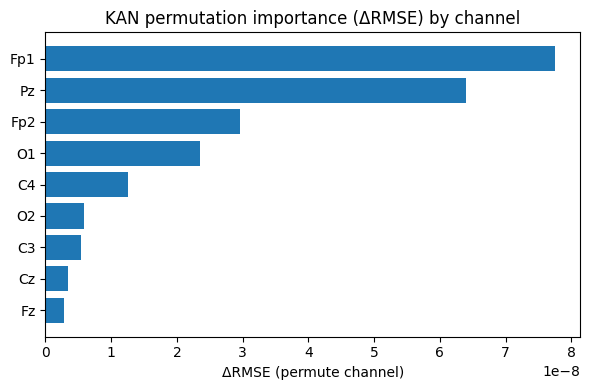

Saved: outputs/kan_permutation_importance.csv


In [ ]:
# ==== KAN permutation importance by channel (test subset) ====
import os, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from torch.utils.data import Subset, DataLoader

rng = np.random.default_rng(cfg.get("random_seed", 42))
C = X.shape[1]
channels = np.load(os.path.join(save_dir, "channels.npy"), allow_pickle=True).tolist()

# Подвыборка теста для быстроты
N_EVAL = min(2048, len(test_ds))
idx = rng.choice(len(test_ds), size=N_EVAL, replace=False)
subset = Subset(test_ds, idx.tolist())
loader = DataLoader(subset, batch_size=min(256, cfg["train"]["batch_size"]), shuffle=False)

# Базовый RMSE (денорм)
model.load_state_dict(torch.load(BEST, map_location=device))
@torch.no_grad()
def _predict(model, loader):
    yh, yt = [], []
    model.eval()
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yh.append(model(xb).cpu().numpy())
        yt.append(yb.cpu().numpy())
    return np.concatenate(yt,0), np.concatenate(yh,0)

ytrue_n, yhat_n = _predict(model, loader)

def _denorm(yhat_n, ytrue_n):
    if cfg["task"]["target_mode"] == "uni":
        yhat  = yhat_n  * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
        ytrue = ytrue_n * (train_std[target_ch_idx] + 1e-6) + train_mean[target_ch_idx]
    else:
        yhat  = yhat_n  * (train_std[:, None] + 1e-6) + train_mean[:, None]
        ytrue = ytrue_n * (train_std[:, None] + 1e-6) + train_mean[:, None]
    return ytrue, yhat

ytrue_b, yhat_b = _denorm(yhat_n, ytrue_n)
rmse_base = rmse(ytrue_b, yhat_b)

# Соберём X_norm для подмножества (чтобы можно было перетасовывать вне GPU)
Xn = np.empty((N_EVAL, C, X.shape[2]), dtype=np.float32)
Yn = np.empty_like(ytrue_n)
for i, (x, y) in enumerate(subset):
    Xn[i] = x.numpy()
    Yn[i] = y.numpy()

def _eval_with_Xn(Xn_perm):
    ds = torch.utils.data.TensorDataset(torch.from_numpy(Xn_perm), torch.from_numpy(Yn))
    dl = DataLoader(ds, batch_size=min(256, cfg["train"]["batch_size"]), shuffle=False)
    ytrue_n2, yhat_n2 = _predict(model, dl)
    ytrue_d, yhat_d   = _denorm(yhat_n2, ytrue_n2)
    return rmse(ytrue_d, yhat_d)

rows = []
for c in range(C):
    Xp = Xn.copy()
    perm = rng.permutation(N_EVAL)
    Xp[:, c, :] = Xp[perm, c, :]
    rmse_perm = _eval_with_Xn(Xp)
    rows.append({"channel": channels[c] if c < len(channels) else f"ch{c}",
                 "delta_RMSE": float(rmse_perm - rmse_base),
                 "rmse_perm": float(rmse_perm)})

imp = pd.DataFrame(rows).sort_values("delta_RMSE", ascending=False).reset_index(drop=True)
display(imp)

# Сохранить и нарисовать
out_dir = cfg["logging"]["out_dir"]
imp.to_csv(os.path.join(out_dir, "kan_permutation_importance.csv"), index=False)
plt.figure(figsize=(6, 4))
plt.barh(imp["channel"], imp["delta_RMSE"])
plt.gca().invert_yaxis()
plt.title("KAN permutation importance (ΔRMSE) by channel")
plt.xlabel("ΔRMSE (permute channel)")
plt.tight_layout()
plt.show()
print("Saved:", os.path.join(out_dir, "kan_permutation_importance.csv"))


In [ ]:
# ==== Export thesis-ready tables & plots ====
import os, json, numpy as np, pandas as pd, matplotlib.pyplot as plt

out_dir = cfg["logging"]["out_dir"]
os.makedirs(out_dir, exist_ok=True)

# 1) Метрики в µV + nRMSE%
factor = 1e6
def smape_stable(y_true, y_pred, tol=1e-3):  # tol в µV
    num = np.abs(y_pred - y_true)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = den >= tol
    if not np.any(mask): return float("nan")
    return float(100.0 * np.mean(num[mask] / den[mask]))

if cfg["task"]["target_mode"] == "uni":
    ytrue_uv = ytrue * factor; yhat_uv = yhat * factor
else:
    ytrue_uv = ytrue.mean(axis=1) * factor
    yhat_uv  = yhat.mean(axis=1)  * factor

mae_uv   = float(np.mean(np.abs(yhat_uv - ytrue_uv)))
rmse_uv  = float(np.sqrt(np.mean((yhat_uv - ytrue_uv)**2)))
rms_tgt  = float(np.sqrt(np.mean(ytrue_uv**2))) + 1e-12
nrmse_pct = float(100.0 * rmse_uv / rms_tgt)
smape_uv = smape_stable(ytrue_uv, yhat_uv, tol=1e-3)

with open(os.path.join(out_dir, "metrics_test_uv.json"), "w") as f:
    json.dump({"MAE_uV": mae_uv, "RMSE_uV": rmse_uv,
               "nRMSE_percent": nrmse_pct, "sMAPE_stable_percent": smape_uv}, f, indent=2)

# 2) Сохранить "true vs pred" (лучший/худший кейсы)
rmse_per_sample = np.sqrt(np.mean((yhat - ytrue)**2, axis=-1)) if cfg["task"]["target_mode"]=="uni" \
                  else np.sqrt(np.mean((yhat.mean(axis=1)-ytrue.mean(axis=1))**2, axis=-1))
best_idx  = int(np.argmin(rmse_per_sample))
worst_idx = int(np.argmax(rmse_per_sample))

def save_example(idx, name):
    plt.figure(figsize=(8,3))
    if cfg["task"]["target_mode"]=="uni":
        plt.plot(ytrue[idx], label="True"); plt.plot(yhat[idx], label="Pred", alpha=0.8)
    else:
        plt.plot(ytrue[idx].mean(axis=0), label="True (mean C)")
        plt.plot(yhat[idx].mean(axis=0), label="Pred (mean C)", alpha=0.8)
    plt.xlabel("Horizon step"); plt.ylabel("Amplitude (V)"); plt.legend()
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, f"{name}.png"), dpi=180); plt.close()

save_example(best_idx,  "case_best")
save_example(worst_idx, "case_worst")

# 3) Лидерборд — столбчатый график
lb = pd.read_csv(os.path.join(out_dir, "leaderboard_test.csv"))
plt.figure(figsize=(6,3))
plt.bar(lb["model"], lb["RMSE"])
plt.ylabel("RMSE (V)"); plt.title("KAN vs Baselines (test)")
plt.xticks(rotation=20); plt.tight_layout()
plt.savefig(os.path.join(out_dir, "leaderboard_bar.png"), dpi=180); plt.close()

# 4) RMSE по горизонту (если файл есть)
hpath = os.path.join(out_dir, "metrics_test_horizon.csv")
if os.path.exists(hpath):
    dfh = pd.read_csv(hpath)
    plt.figure(figsize=(6,3)); plt.plot(dfh["k"], dfh["rmse"])
    plt.xlabel("Step k"); plt.ylabel("RMSE (V)"); plt.title("RMSE vs forecast horizon")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, "rmse_horizon.png"), dpi=180); plt.close()

print("Saved figures to:", out_dir)


Saved figures to: outputs
